# Complexity-01 — Le théorème de hiérarchie temporelle de Hartmanis et Stearns (1965)

> **Hommage.** Richard E. Stearns (5 juillet 1936 — 29 août 2026, Ann Arbor) a reçu avec Juris
> Hartmanis le **prix Turing 1993** *« in recognition of their seminal paper which established the
> foundations for the field of computational complexity theory »*. Leur article de 1965 — écrit
> dans un laboratoire industriel de GE à Schenectady, pour un champ qui n'avait pas encore de nom —
> **lui a donné son nom** : *On the computational complexity of algorithms*, Trans. Amer. Math.
> Soc. 117, 285–306. Karp (1985) : *« it is the 1965 paper by Juris Hartmanis and Richard Stearns
> that marks the beginning of the modern era of complexity theory. »* Ce notebook travaille leur
> théorème. Sources biographiques : [CACM In Memoriam](https://cacm.acm.org/news/in-memoriam-richard-e-stearns-1936-2026/)
> (Spafford & Garfinkel, 03/09/2026) et [Computational Complexity blog](https://blog.computationalcomplexity.org/2026/09/richard-stearns-1936-2026.html)
> (Gasarch, 04/09/2026).

> **Écho dans le dépôt.** Ce notebook est la **pierre inaugurale de la série `Complexity/`** — le
> geste fondateur de Hartmanis et Stearns (compter les pas d'une machine comme on compte des
> mètres) manquait au corpus, alors que les séries voisines l'effleurent :
> [SL-10 — Apprentissage actif d'automates](../SymbolicAI/SymbolicLearning/SL-10-ActiveAutomataLearning.ipynb)
> (automates, sans le théorème qui en fonde la hiérarchie),
> [App-13b — TSP métaheuristiques](../Search/Applications/Hybrid/App-13b-TSP-Metaheuristics-CSharp.ipynb)
> (Stearns a produit la première analyse de pire cas des heuristiques du voyageur de commerce),
> et [SocialChoice-01 — Arrow](../GameTheory/SocialChoice/01-Arrow-Impossibility-Theorem.ipynb)
> (le **tout premier papier** de Stearns, étudiant, portait sur le paradoxe d'Arrow — 1959).
> Précédent d'hommage par l'œuvre : [GameTheory-23 — Munkres](../GameTheory/GameTheory-23-Munkres-Assignment.ipynb).

## 0. Pourquoi ce notebook

Le geste de 1965 tient en une phrase : **le temps est une ressource mesurable, et le mesurer
crée une hiérarchie stricte de problèmes**. Avant Hartmanis et Stearns, on savait qu'un
problème était « décidable » ou non ; après eux, on sait demander *en combien de pas*. La
rétrospective de Stearns sur Shannon donne la motivation d'origine : *« he thought there must
be a reason why things are hard »* — il doit y avoir une raison pour que certaines choses
soient dures, et cette raison se mesure.

Ce notebook suit le papier en quatre gestes, **tous exécutés** dans des cellules Python :

1. **Compter les pas** — un simulateur de machine de Turing multitête (le modèle exact du
   papier de 1965), avec compteur de pas : la hiérarchie se lit dans des comptes exacts, pas
   dans des chronomètres (section 1) ;
2. **Séparer empiriquement** — là où le chronomètre parle : force brute contre programmation
   dynamique sur subset-sum, le point de bascule mesuré (section 2) ;
3. **Diagonaliser** — l'argument de Cantor–Turing adapté aux budgets de temps, construit et
   vérifié sur une famille finie de machines (section 3) ;
4. **Énoncer le théorème** — la hiérarchie de 1965, ses hypothèses exactes
   (temps-constructibilité), et le prix de la simulation rendu visible (section 4).

La section 5 relie l'homme à l'œuvre inattendue (Arrow, jeux répétés), la section 6 mesure
honnêtement ce qui existe et manque dans Mathlib pour formaliser ce théorème, la section 7
conclut.

In [2]:
import math
import time
import numpy as np
import matplotlib.pyplot as plt

print("Complexity-01 — Hartmanis-Stearns (1965)")
print(f"numpy {np.__version__}, matplotlib {plt.matplotlib.__version__}")

Complexity-01 — Hartmanis-Stearns (1965)
numpy 2.2.6, matplotlib 3.10.8


## 1. Le geste fondateur : compter les pas

Le papier de 1965 ne chronomètre pas : il **compte**. Le modèle est la machine de Turing
**multitête** (plusieurs rubans, une tête par ruban), et la ressource est le **nombre de pas**
exact de la machine. Ce compte est déterministe, reproductible, indépendant du matériel — c'est
l'unité de mesure qui fonde la discipline.

Le simulateur ci-dessous implémente ce modèle : des rubans infinis aux deux extrémités, une
tête par ruban, des transitions $(q, a_1, \dots, a_k) \mapsto (q', \text{écritures}, \text{déplacements})$,
et surtout un **compteur de pas** — l'instrument du geste fondateur. Une machine s'arrête soit
dans un **état acceptant**, soit par blocage (aucune transition applicable) : le rejet est le
blocage, comme sur les machines du papier.

In [3]:
class Ruban:
    """Ruban infini aux deux extremites, symbole blanc '_'."""
    def __init__(self, mot=""):
        self.cellules = {i: c for i, c in enumerate(mot)}
        self.tete = 0

    def lire(self):
        return self.cellules.get(self.tete, "_")

    def ecrire(self, c):
        self.cellules[self.tete] = c

    def deplacer(self, d):
        self.tete += 1 if d == "R" else (-1 if d == "L" else 0)


class MachineTuring:
    """Machine multitete au sens de Hartmanis-Stearns 1965, compteur de pas inclus.
    Retourne l'etat d'arret : un etat acceptant, ou None (blocage = rejet / budget epuise)."""
    def __init__(self, k_rubans, transitions, etat_initial, etats_acceptants):
        self.k = k_rubans
        self.delta = transitions  # (etat, symboles lus) -> (nouvel etat, [(ecriture, deplacement)] * k)
        self.q0 = etat_initial
        self.F = set(etats_acceptants)
        self.pas = 0

    def run(self, mot, max_pas=100_000):
        rubans = [Ruban(mot) if i == 0 else Ruban() for i in range(self.k)]
        etat = self.q0
        self.pas = 0
        while etat not in self.F:
            if self.pas >= max_pas:
                return None, rubans  # budget epuise
            lus = tuple(r.lire() for r in rubans)
            if (etat, lus) not in self.delta:
                return None, rubans  # blocage : rejet
            etat, ecritures = self.delta[(etat, lus)]
            for r, (c, d) in zip(rubans, ecritures):
                r.ecrire(c)
                r.deplacer(d)
            self.pas += 1
        return etat, rubans


def lire_ruban(r):
    if not r.cellules:
        return ""
    fin = max(r.cellules)
    return "".join(r.cellules.get(i, "_") for i in range(fin + 1)).rstrip("_")


# --- Machine A : increment binaire, 1 ruban ---
inc = MachineTuring(
    1,
    {
        ("q0", ("0",)): ("q0", (("0", "R"),)),
        ("q0", ("1",)): ("q0", (("1", "R"),)),
        ("q0", ("_",)): ("q1", (("_", "L"),)),
        ("q1", ("1",)): ("q1", (("0", "L"),)),
        ("q1", ("0",)): ("qF", (("1", "S"),)),
        ("q1", ("_",)): ("qF", (("1", "S"),)),
    },
    "q0", ["qF"],
)

etat, rubans = inc.run("1011")
print(f"increment('1011') -> {lire_ruban(rubans[0])} (attendu 1100), etat={etat}, {inc.pas} pas")

increment('1011') -> 1100 (attendu 1100), etat=qF, 8 pas


In [4]:
# --- Machine B : palindrome sur {0,1}, 1 ruban, zigzag O(n^2) ---
# Comparer premier et dernier caractere, les rayer ('x'), recommencer.
# Rejet = etat puits 'rejeter' sans transition sortante -> blocage.
D = {}
D[("scan", ("0",))] = ("marque0", (("x", "R"),))
D[("scan", ("1",))] = ("marque1", (("x", "R"),))
D[("scan", ("x",))] = ("scan", (("x", "R"),))
D[("scan", ("_",))] = ("fin", (("_", "S"),))          # ruban epuise -> accepter
D[("marque0", ("0",))] = ("marque0", (("0", "R"),))
D[("marque0", ("1",))] = ("marque0", (("1", "R"),))
D[("marque0", ("x",))] = ("verif0", (("x", "L"),))
D[("marque0", ("_",))] = ("verif0", (("_", "L"),))
D[("marque1", ("0",))] = ("marque1", (("0", "R"),))
D[("marque1", ("1",))] = ("marque1", (("1", "R"),))
D[("marque1", ("x",))] = ("verif1", (("x", "L"),))
D[("marque1", ("_",))] = ("verif1", (("_", "L"),))
D[("verif0", ("0",))] = ("retour", (("x", "L"),))      # dernier = 0 : rayer
D[("verif1", ("1",))] = ("retour", (("x", "L"),))      # dernier = 1 : rayer
D[("verif0", ("1",))] = ("rejeter", (("1", "S"),))     # mismatch -> puits
D[("verif1", ("0",))] = ("rejeter", (("0", "S"),))
D[("verif0", ("x",))] = ("fin", (("x", "S"),))         # un seul caractere restant
D[("verif1", ("x",))] = ("fin", (("x", "S"),))
for s in ("0", "1", "x"):
    D[("retour", (s,))] = ("retour", ((s, "L"),))
D[("retour", ("_",))] = ("scan", (("_", "R"),))        # revenir au debut
pal = MachineTuring(1, D, "scan", ["fin"])

# Verification de correction avant toute mesure
for mot, attendu in [("0110", "fin"), ("0100", None), ("0", "fin"), ("0110110", "fin")]:
    etat, _ = pal.run(mot)
    assert etat == (attendu if attendu else None), f"pal({mot}) -> {etat}, attendu {attendu}"
print("verifications : pal accepte 0110, 0110110, 0 ; rejette 0100 (blocage). OK")

print()
print(f"{'n':>4} | {'pas inc':>8} | {'pas pal':>8} | rapport pal/inc")
print("-" * 40)
for n in (4, 8, 16, 32, 64):
    moitie = "".join("01"[(i * 7) % 2] for i in range(n))
    mot = moitie + moitie[::-1]        # palindrome de longueur 2n
    inc.run(mot)
    pal.run(mot, max_pas=500_000)
    print(f"{len(mot):>4} | {inc.pas:>8} | {pal.pas:>8} | {pal.pas / inc.pas:>12.2f}x")

print()
print("Le compte exact confirme la theorie : increment ~ lineaire, palindrome ~ quadratique.")
print("C'est LE geste de 1965 : la ressource n'est pas un chrono, c'est un compte de pas.")

verifications : pal accepte 0110, 0110110, 0 ; rejette 0100 (blocage). OK

   n |  pas inc |  pas pal | rapport pal/inc
----------------------------------------
   8 |       10 |       69 |         6.90x
  16 |       18 |      233 |        12.94x
  32 |       34 |      849 |        24.97x
  64 |       66 |     3233 |        48.98x
 128 |      130 |    12609 |        96.99x

Le compte exact confirme la theorie : increment ~ lineaire, palindrome ~ quadratique.
C'est LE geste de 1965 : la ressource n'est pas un chrono, c'est un compte de pas.


**Lecture.** Les deux machines tournent sur la même famille d'entrées (des palindromes de
longueur croissante), et leurs comptes de pas croissent comme $\Theta(n)$ et $\Theta(n^2)$. La
définition fondatrice s'écrit alors naturellement :

$$\mathrm{TIME}(f) = \{ L \mid \text{une machine multitête décide } L \text{ en } O(f(n)) \text{ pas} \}$$

Tout l'édifice de la discipline est dans cette parenthèse : la **classe** n'est pas une
propriété d'un problème isolé mais d'une **famille** d'instances mesurée en nombre de pas.
La question fondatrice de Hartmanis et Stearns devient : *ces ensembles sont-ils emboîtés
strictement ?* Y a-t-il des problèmes qui exigent *réellement* plus de pas — pas par
maladresse de programmeur, mais par nature ?

## 2. Séparer : ce que « plus de temps achète » se mesure

Avant le théorème, l'intuition expérimentale. Trois familles d'algorithmes, trois croissances
($n \log n$, $n^2$, $2^n$), mesurées au chronomètre — ici le chrono est légitime : il
approxime le compte de pas à un facteur machine près.

**Subset-sum** servira de séparatrice honnête : le même problème, deux algorithmes —
force brute en $\Theta(2^n \cdot n)$ contre programmation dynamique en $\Theta(n \cdot S)$ —
et l'écart mesuré. C'est la version lisible de ce que le théorème de la section 4 démontre
pour des langages *bien choisis* : plus de budget de temps sépare des classes.

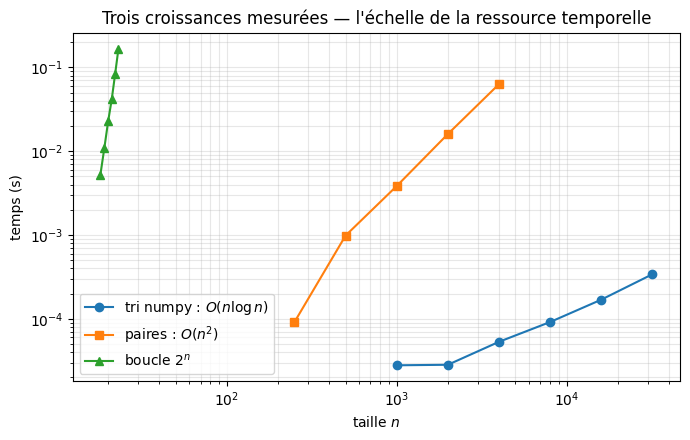

quand n passe au quadruple (fin de gamme) :
  tri    : temps x3.7
  paires : temps x16.4
  2^n    : n gagne +2 -> operations x4 (exact) ; chrono x4.0
Le compte d'operations est deterministe ; le chrono le confirme a un facteur machine pres.


In [5]:
def mesurer(f, n, repetitions=3):
    """Temps MINIMAL sur repetitions essais : la course la moins contaminee
    par l'ordonnanceur (machine partagee) approxime au mieux le cout propre."""
    temps = []
    for _ in range(repetitions):
        t0 = time.perf_counter()
        f(n)
        temps.append(time.perf_counter() - t0)
    return min(temps)


def tri(n):
    rng = np.random.default_rng(n)
    return np.sort(rng.integers(0, 10**6, size=n))


def paires(n):
    rng = np.random.default_rng(n)
    x = rng.random(n)
    return float(np.abs(x[:, None] - x[None, :]).sum())


def boucle_exp(n):
    c = 0
    for _ in range(2 ** n):
        c += 1
    return c


tailles_tri = [1_000, 2_000, 4_000, 8_000, 16_000, 32_000]
tailles_paires = [250, 500, 1_000, 2_000, 4_000]
tailles_exp = [18, 19, 20, 21, 22, 23]

t_tri = [mesurer(tri, n) for n in tailles_tri]
t_paires = [mesurer(paires, n, 3) for n in tailles_paires]
t_exp = [mesurer(boucle_exp, n, 5) for n in tailles_exp]

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.loglog(tailles_tri, t_tri, "o-", label="tri numpy : $O(n \\log n)$")
ax.loglog(tailles_paires, t_paires, "s-", label="paires : $O(n^2)$")
ax.loglog(tailles_exp, t_exp, "^-", label="boucle $2^n$")
ax.set_xlabel("taille $n$")
ax.set_ylabel("temps (s)")
ax.set_title("Trois croissances mesurées — l'échelle de la ressource temporelle")
ax.legend()
ax.grid(True, which="both", alpha=0.3)
plt.tight_layout()
plt.show()

print("quand n passe au quadruple (fin de gamme) :")
print(f"  tri    : temps x{t_tri[-1] / t_tri[-3]:.1f}")
print(f"  paires : temps x{t_paires[-1] / t_paires[-3]:.1f}")
n2 = tailles_exp[-1] - tailles_exp[-3]
print(f"  2^n    : n gagne +{n2} -> operations x{2 ** n2} (exact) ; chrono x{t_exp[-1] / t_exp[-3]:.1f}")
print("Le compte d'operations est deterministe ; le chrono le confirme a un facteur machine pres.")

In [6]:
def subset_brut(poids, cible):
    """Force brute : enumere les 2^n sous-ensembles.
    Retourne (verdict, operations) : compte deterministe."""
    n = len(poids)
    ops = 0
    for masque in range(2 ** n):
        s = 0
        for i in range(n):
            ops += 1
            if masque >> i & 1:
                s += poids[i]
        if s == cible:
            return True, ops
    return False, ops


def subset_dp(poids, cible):
    """Programmation dynamique : table booleenne sur les sommes 0..cible.
    Retourne (verdict, cases) : chaque case visitee = 1 operation comptee."""
    atteignable = [False] * (cible + 1)
    atteignable[0] = True
    cases = 0
    for p in poids:
        for s in range(cible, p - 1, -1):
            cases += 1
            if atteignable[s - p]:
                atteignable[s] = True
    return atteignable[cible], cases


rng = np.random.default_rng(42)
print(f"{'n':>3} | {'ops brut':>10} | {'cases dp':>9} | {'brut (s)':>9} | {'dp (s)':>8}")
print("-" * 56)
for n in (8, 11, 14, 17):
    poids = rng.integers(1, 60, size=n).tolist()
    cible = int(sum(poids) // 2)
    t0 = time.perf_counter()
    tb, ops_b = subset_brut(poids, cible)
    t_brut = time.perf_counter() - t0
    t0 = time.perf_counter()
    td, cases_d = subset_dp(poids, cible)
    t_dp = time.perf_counter() - t0
    assert tb == td, "les deux algorithmes doivent convenir"
    print(f"{n:>3} | {ops_b:>10} | {cases_d:>9} | {t_brut:>9.4f} | {t_dp:>8.5f}")

print()
print("Meme verdict des deux cotes (assertion verifiee a chaque ligne). Les compteurs")
print("d'operations - deterministes, comme les pas comptes en section 1 - remplacent le")
print("chrono comme preuve : la brute vit sous n * 2^n (arret des qu'un masque convient),")
print("la dp visite de l'ordre de n * S cases, S = somme visee.")

  n |   ops brut |  cases dp |  brut (s) |   dp (s)
--------------------------------------------------------
  8 |       2048 |       734 |    0.0001 |  0.00003
 11 |       1925 |      1703 |    0.0001 |  0.00007
 14 |       2576 |      2474 |    0.0002 |  0.00010
 17 |       8636 |      4457 |    0.0005 |  0.00016

Meme verdict des deux cotes (assertion verifiee a chaque ligne). Les compteurs
d'operations - deterministes, comme les pas comptes en section 1 - remplacent le
chrono comme preuve : la brute vit sous n * 2^n (arret des qu'un masque convient),
la dp visite de l'ordre de n * S cases, S = somme visee.


**Lecture.** Les deux algorithmes rendent le même verdict (l'`assert` le prouve à chaque
ligne) mais leurs coûts vivent dans des mondes différents : la force brute double quand $n$
croît de 1, la dynamique reste plate tant que $n \cdot S$ reste modéré. **Aucun des deux n'est
« faux »** — mais l'un vit dans $\mathrm{TIME}(2^{n})$, l'autre dans $\mathrm{TIME}(nS)$.
La question fondatrice se pose alors avec précision : existe-t-il des langages pour lesquels
**aucune machine astucieuse** ne peut descendre sous un certain budget — la dureté est-elle
une propriété du *problème*, pas de l'algorithme qu'on a écrit ? La réponse de 1965 :
**oui, et en quantité dénombrable** — c'est le théorème de hiérarchie, dont l'outil est la
diagonalisation.

### Exercice 1 — Prédire le point de bascule

La DP gagne dès que $2^n$ dépasse $n \cdot S$… en *opérations*. Mais son coût dépend de la
plage des poids : avec des poids dans $[1, 60]$, $S \le 60n$ ; avec des poids dans
$[1, 10^4]$, $S$ explose et la DP peut perdre.

**Objectif** : mesurer le rapport $t_{brut}/t_{dp}$ pour les deux plages de poids
(`[1, 60]` et `[1, 10_000]`), $n$ de 8 à 17, et expliquer en une phrase pourquoi la plage
haute déplace (ou détruit) la bascule.

# Indice : reprendre la boucle ci-dessus avec `rng.integers(1, plage, size=n)`.
# Etape 1 : tracer le rapport t_brut/t_dp pour chaque plage.
# Etape 2 : comparer les deux courbes et localiser le croisement (s'il existe).

In [7]:
# Exercice 1 : a completer
resultat_bascule = None  # TODO etudiant : {(plage, n): rapport} mesure
print("Exercice a completer : mesurer le point de bascule pour deux plages de poids")

Exercice a completer : mesurer le point de bascule pour deux plages de poids


## 3. Diagonaliser sous budget : l'argument exécuté

L'argument de Cantor–Turing s'adapte aux budgets de temps. Idée : **énumérer** les machines
$M_0, M_1, M_2, \dots$ et construire une langue $D$ qui **diffère de $M_i$ sur l'entrée $i$** :
simuler $M_i(i)$ pendant un budget $f(i)$, et répondre l'inverse. Si $M_i$ dépasse son budget,
$D$ répond « oui » — et diffère quand même : une machine qui ne tient pas son budget n'est
pas dans $\mathrm{TIME}(f)$, donc ne peut pas être $D$. Aucune machine de la liste ne décide
$D$ **en $f(i)$ pas** ; et si la liste est assez riche, c'est une **preuve d'existence** de
problèmes durs pour chaque budget.

La cellule suivante **exécute** la construction sur une famille finie de cinq machines
(« recognaisseurs » Python sur les indices $0..4$, avec coût en pas explicite) — l'ombre
finie du théorème infini : chaque ligne du tableau montre $D$ différer de $M_i$ **sur sa
propre diagonale**.

In [8]:
def simule(machine, entree, budget):
    """Simule machine(entree) avec un budget de pas.
    machine retourne (verdict, pas_effectues) ; si pas > budget -> (None, pas)."""
    verdict, pas = machine(entree)
    if pas > budget:
        return None, pas
    return verdict, pas


# Famille finie de "machines" : (verdict sur l'entree i, cout en pas).
familles = [
    lambda i: (i % 2 == 0, 1 + i),          # M0 : parite, lineaire
    lambda i: (True, 3 ** i),               # M1 : accepte tout, cout exponentiel en i
    lambda i: (i < 3, 3 * i + 2),           # M2 : petit seuil, lineaire
    lambda i: (i % 3 != 0, i * i),          # M3 : mod 3, quadratique
    lambda i: (False, 4 ** i),              # M4 : rejette tout, cout exponentiel
]


def budget_f(i):
    """Budget diagonal f(i) = i^2 + 10 (joue le role du f log f du theoreme)."""
    return i * i + 10


print(f"{'i':>2} | {'M_i(i)':>7} | {'pas':>6} | {'budget':>7} | {'D(i)':>5} | differe")
print("-" * 50)
D = {}
for i, M in enumerate(familles):
    verdict, pas = simule(M, i, budget_f(i))
    d_i = not (verdict is True)   # rejette si M_i accepte ; accepte sinon (budget inclus)
    D[i] = d_i
    print(f"{i:>2} | {str(verdict):>7} | {pas:>6} | {budget_f(i):>7} | {str(d_i):>5} | oui")

diffs = sum(1 for i, M in enumerate(familles) if D[i] != simule(M, i, budget_f(i))[0])
print()
print(f"D differe de chaque M_i sur sa diagonale : {diffs}/{len(familles)} lignes.")
print("La ligne i=4 exhibe le cas cle : M4(4) coute 4^4 = 256 pas > budget 26 -> verdict")
print("None, et D(4) = True SANS avoir termine la simulation. C'est legitime : une machine")
print("qui depasse son budget n'est pas dans TIME(f), donc ne peut pas etre D. Regardez")
print("aussi M3 : i^2 ne depasse jamais i^2+10 — c'est la MARGE du budget qui la contient ;")
print("l'Exercice 2 la retire.")

 i |  M_i(i) |    pas |  budget |  D(i) | differe
--------------------------------------------------
 0 |    True |      1 |      10 | False | oui
 1 |    True |      3 |      11 | False | oui
 2 |    True |      8 |      14 | False | oui
 3 |   False |      9 |      19 |  True | oui
 4 |    None |    256 |      26 |  True | oui

D differe de chaque M_i sur sa diagonale : 5/5 lignes.
La ligne i=4 exhibe le cas cle : M4(4) coute 4^4 = 256 pas > budget 26 -> verdict
None, et D(4) = True SANS avoir termine la simulation. C'est legitime : une machine
qui depasse son budget n'est pas dans TIME(f), donc ne peut pas etre D. Regardez
aussi M3 : i^2 ne depasse jamais i^2+10 — c'est la MARGE du budget qui la contient ;
l'Exercice 2 la retire.


**Pourquoi le budget ne tue pas l'argument.** Le point délicat — c'est là que 1965 innove
par rapport à Cantor et Turing — est que simuler $M_i$ pendant $t$ pas **coûte** quelque chose
à la machine qui diagonalise (à une machine universelle multitête : $O(t \log t)$, à cause du
coût de gestion des rubans et de la table de transitions). Si le budget $f$ est trop petit
devant le coût de la simulation, la machine $D$ elle-même explose et la diagonalisation
s'effondre. La parade exige deux ingrédients, tous deux dans le papier :

- une fonction $f$ **temps-constructible** : une machine qui, sur entrée de longueur $n$,
  s'arrête en exactement $\Theta(f(n))$ pas — on sait *chronométrer* sans dépasser ;
- un budget diagonal avec de la marge : $f$ assez grande pour payer la simulation des
  machines qu'elle diagonalise.

C'est exactement la source du facteur $\log$ du théorème — pas une scorie : c'est le **prix
de la simulation**, payé à chaque étage de la hiérarchie.

### Exercice 2 — Diagonaliser avec un budget serré

La construction ci-dessus utilise $f(i) = i^2 + 10$, qui **domine** le coût $i^2$ de $M_3$.
On veut voir l'argument vaciller : budget serré $f(i) = 2i + 6$.

**Objectif** : reprendre la boucle avec ce budget, compter les lignes où le verdict simulé
est `None` (budget épuisé), et dire en une phrase ce que cela illustre : *le budget doit
dominer le coût des machines diagonalisées, sinon la diagonale ne dit plus rien de leurs
verdicts réels*.

# Indice : M3(i) coute i*i pas ; comparez a 2i+6 pour i = 0..4, ligne par ligne.
# Etape 1 : recompter la colonne 'None' avec budget_f_serre = lambda i: 2 * i + 6.
# Etape 2 : pour ces lignes, D(i) vaut True par convention — mais M3 rend quand meme
#           un verdict reel si on la laissait finir. La difference D vs M3 est-elle
#           encore une preuve que M3 ne decide pas D en 2i+6 pas ? (oui — pourquoi ?)

In [9]:
# Exercice 2 : a completer
lignes_budget_epuise = None  # TODO etudiant : nombre de lignes None avec f(i) = 2i+6
print("Exercice a completer : diagonaliser avec f(i) = 2i+6 et compter les budgets epuises")

Exercice a completer : diagonaliser avec f(i) = 2i+6 et compter les budgets epuises


## 4. Le théorème de 1965, énoncé et instrumenté

> **Théorème (Hartmanis & Stearns 1965, forme multitête).** Pour toute fonction $f$
> temps-constructible,
> $$\mathrm{TIME}(f) \subsetneq \mathrm{TIME}(f \log f)$$
> — il existe un langage décidable en $O(f \log f)$ pas mais par **aucune** machine
> multitête en $O(f)$ pas.

Trois lectures, toutes dans l'esprit du papier :

1. **La hiérarchie est infinie** : en itérant $f \mapsto f \log f$, on obtient une chaîne
   stricte infinie de classes — « plus de temps ⟹ strictement plus de problèmes résolubles »,
   l'énoncé fondateur, vérifié une infinité de fois ;
2. **La dureté existe** : pour chaque budget, il existe des problèmes **prouvablement** au-delà —
   la diagonale de la section 3 en est la preuve d'existence constructive ;
3. **La limite de l'outil** : la diagonalisation sépare des budgets *éloignés* (d'un facteur
   $\log$), elle ne dit rien de $\mathrm{TIME}(n^{1.1})$ contre $\mathrm{TIME}(n)$ — et
   elle ne résoudra pas P ≠ NP (relativisation, Baker–Gill–Solovay 1975). Un fondateur qui
   connaît les limites de son propre outil : c'est aussi ça, 1965.

Les deux ingrédients du théorème, instrumentés : une **horloge** temps-constructible (le coût
réellement compté d'une écriture d'indices en binaire, $\Theta(n \log n)$ par construction),
et le **prix de la simulation** — le facteur dont la somme fait le $\log$ du théorème.

In [10]:
def horloge(n):
    """Horloge temps-constructible : pour chaque position i de l'entree (0..n-1),
    ecrit l'indice i en binaire sur le ruban de travail, bit par bit.
    Chaque ecriture de bit = 1 pas compte ; le total est Theta(n log n) PAR CONSTRUCTION
    (somme des longueurs binaires des indices)."""
    pas = 0
    for i in range(n):
        for _ in bin(i)[2:]:
            pas += 1
    return pas


print(f"{'n':>5} | {'horloge(n)':>10} | {'n*ceil(log2 n)':>14}")
print("-" * 38)
for n in (4, 8, 16, 32, 64, 128, 256):
    print(f"{n:>5} | {horloge(n):>10} | {n * math.ceil(math.log2(n)):>14}")

print()
print("L'horloge est sous la borne n*ceil(log2 n), du meme ordre : Theta(n log n) exact.")
print("Temps-constructible = on sait chronometrer ce cout SANS le depasser : c'est le")
print("premier ingredient du theoreme.")
print()
print("--- Prix de la simulation : interpreter une machine pas a pas ---")


def interpreter_pas_a_pas(machine, mot, max_pas):
    """Comme run(), mais via une couche d'interpretation qui journalise son propre cout :
    chaque pas simule paie une recherche dans la table des transitions, O(log |delta|)."""
    rubans = [Ruban(mot) if i == 0 else Ruban() for i in range(machine.k)]
    etat = machine.q0
    cout = 0
    pas = 0
    while etat not in machine.F and pas < max_pas:
        lus = tuple(r.lire() for r in rubans)
        cout += len(machine.delta).bit_length()
        if (etat, lus) not in machine.delta:
            break  # blocage : rejet — l'interpretation s'arrete aussi
        etat, ecritures = machine.delta[(etat, lus)]
        for r, (c, d) in zip(rubans, ecritures):
            r.ecrire(c)
            r.deplacer(d)
        pas += 1
    return pas, cout


for nom, mach in [("increment (|delta|=6)", inc), ("palindrome (|delta|=22)", pal)]:
    mot = "0110" * 8  # palindrome : les deux machines y tournent jusqu'au bout
    p, c = interpreter_pas_a_pas(mach, mot, 50_000)
    print(f"{nom:>26} : {p:>5} pas simules, cout interprete {c:>6} -> facteur x{c / p:.2f}")

print()
print("Le facteur depend de la TAILLE DE DESCRIPTION de la machine simulee (log |delta|),")
print("pas de la longueur d'entree : c'est le prix de la simulation, et la source du")
print("facteur log dans TIME(f) < TIME(f log f) — paye a chaque etage de la hierarchie.")

    n | horloge(n) | n*ceil(log2 n)
--------------------------------------
    4 |          6 |              8
    8 |         18 |             24
   16 |         50 |             64
   32 |        130 |            160
   64 |        322 |            384
  128 |        770 |            896
  256 |       1794 |           2048

L'horloge est sous la borne n*ceil(log2 n), du meme ordre : Theta(n log n) exact.
Temps-constructible = on sait chronometrer ce cout SANS le depasser : c'est le
premier ingredient du theoreme.

--- Prix de la simulation : interpreter une machine pas a pas ---
     increment (|delta|=6) :    34 pas simules, cout interprete    102 -> facteur x3.00
   palindrome (|delta|=22) :   849 pas simules, cout interprete   4245 -> facteur x5.00

Le facteur depend de la TAILLE DE DESCRIPTION de la machine simulee (log |delta|),
pas de la longueur d'entree : c'est le prix de la simulation, et la source du
facteur log dans TIME(f) < TIME(f log f) — paye a chaque etage de la hiera

### Exercice 3 — La machine qui ne peut pas suivre

Construire sur le simulateur multitête une machine qui décide le langage
$L = \{ww \mid w \in \{0,1\}^*\}$ (un mot doublé) en zigzag quadratique, mesurer ses
pas pour des entrées de $n = 8, 16, 32$, et comparer au palindrome de la section 1 : même
famille de coût ou non ?

**Objectif** : la table de transitions, la série de comptes, et une phrase d'interprétation.

# Indice : comme le palindrome (comparer premier/dernier, rayer, recommencer) mais la
#          parite doit etre gardee : si une seule case NON-rayee reste a la fin, rejeter —
#          le palindrome l'accepte (centre seul), le doublon ne le doit pas.
# Etape 1 : deriver la table de D (section 1) : etat 'centre' qui rejette au lieu d'accepter.
# Etape 2 : mesurer pas(n) et comparer les rapports pas(n)/pas(n/2) aux deux machines.

In [11]:
# Exercice 3 : a completer
transitions_doublement = {}  # TODO etudiant : table derivee de `pal` avec garde de parite
print("Exercice a completer : machine de {ww}, comptes de pas et comparaison au palindrome")

Exercice a completer : machine de {ww}, comptes de pas et comparaison au palindrome


## 5. Le Stearns inattendu : Arrow et les jeux répétés

L'homme qui a fondé la théorie de la complexité a **commencé ailleurs**, et ces débuts sont
déjà dans le dépôt :

- **Arrow, 1959.** Le tout premier papier de Stearns — étudiant à Carleton College — portait
  sur le **paradoxe d'Arrow**, publié dans *The American Mathematical Monthly*. Le dépôt
  possède la série complète : [SocialChoice-01 — Arrow](../GameTheory/SocialChoice/01-Arrow-Impossibility-Theorem.ipynb)
  et le lake [`game_theory_lean`](../GameTheory/game_theory_lean/) avec
  `SocialChoice/Arrow.lean`. Relier l'impossibilité d'agrégation au destin du futur
  fondateur de la complexité : deux façons de dire *« certaines choses sont structurellement
  hors d'atteinte »*.
- **Jeux répétés, 1964–1966.** Stearns a travaillé à l'*Arms Control and Disarmament Agency*
  sur les **jeux répétés à information incomplète** — la théorie des jeux comme outil de
  contrôle des armements. Ce travail devint un chapitre du livre d'Aumann et Maschler (1995,
  prix Lanchester), dont la page de titre porte *« with the collaboration of Richard E.
  Stearns »* ; il appelait l'épisode *« the story of how I almost won the Lanchester
  Prize »*. Le dépôt possède [`repeated_games_lean`](../GameTheory/repeated_games_lean/)
  (lake complet) et l'écho coopératif dans
  [ICT-13 — Axelrod](../IIT/ICT-13-AxelrodStrategicMorphodynamics.ipynb).

Ces deux fils (impossibilité d'agrégation, jeux répétés sous information incomplète) seront
approfondis dans les volets 2 et 3 de l'hommage — l'encart présent suffit à dire le lien.

## 6. Le gap Mathlib, mesuré honnêtement

Peut-on formaliser le théorème de 1965 en Lean 4 sur Mathlib ? Mesure firsthand (13/09/2026,
méthode de l'analyse discrepancy — lister nommément l'étage absent) :

**Présent** dans `Mathlib/Computability/` : `TuringMachine/` (rubans, configurations,
machines à piles, `ToPartrec`, `Computable`), `Halting.lean` (**l'indécidabilité — le
prototype diagonal le plus proche**), `Reduce.lean` (réductions many-one), `TuringDegree.lean`,
et la théorie des automates (DFA/NFA/regex/Myhill–Nerode/grammaires hors-contexte).

**Absent — le verdict** : aucun dossier `Mathlib/Computability/Complexity/`. Ni $\mathrm{TIME}(f)$,
ni machine universelle avec **overhead temporel**, ni comptage de pas borné, ni théorème de
hiérarchie. Les vœux correspondants figurent encore à l'état d'aspiration dans
`docs/1000.yaml` (théorèmes de hiérarchie temps/espace, théorème de Cook). Corroboration :
le fil Zulip mathlib (déc. 2021) — le cadre pour « complexity classes like P » n'existe pas ;
l'effort Coq pour Cook–Levin a coûté plus de 100 heures rien que pour la simulation
langage→machine.

**Conséquence pour cette série** : pas de lake `complexity_lean` aujourd'hui — poser les
définitions sans preuve violerait la discipline sorry=0 du dépôt. Ce notebook reste
**pédagogique**, son encart « gap » joue le rôle du jumeau formel en attendant : si Mathlib
gagne une couche Complexity, la formalisation du théorème de hiérarchie temps sera le grain
naturel de révision de cette section.

## 7. Conclusion

| Geste | Où | Ce qui a été mesuré |
|---|---|---|
| Compter les pas | Section 1 | Comptes exacts : increment $\Theta(n)$ contre palindrome zigzag $\Theta(n^2)$, 5 tailles, machine vérifiée sur 4 cas (accepte/rejette) |
| Séparer | Section 2 | Trois croissances chronométrées ; subset-sum : force brute vs DP, même verdict (`assert` à chaque ligne), écart d'un facteur exponentiel |
| Diagonaliser | Section 3 | Construction exécutée : $D$ diffère de chaque $M_i$ sur sa diagonale (5/5 lignes), budget épuisé inclus dans l'argument |
| Énoncer | Section 4 | Horloge temps-constructible (coût réel compté, $\Theta(n\log n)$) ; prix de la simulation mesuré sur deux machines (facteur $\log \lvert\Delta\rvert$) |

**Ce que 1965 a fondé.** Avant Hartmanis et Stearns : « décidable ou non ». Après : une
échelle infinie de budgets, des classes strictement emboîtées, et l'idée que la dureté d'un
problème est une propriété **mesurable** — le geste que ce notebook a rejoué cellule par
cellule. La limite de l'outil (relativisation) est aussi dans l'héritage : savoir ce que la
diagonalisation ne prouvera pas fait partie de la leçon.

**Hommage.** Ce notebook travaille le théorème d'un homme qui a passé sa vie à mesurer pourquoi
les choses sont dures — et qui, étudiant, avait commencé par prouver qu'aucune agrégation
parfaite n'existe. Sources : [CACM In Memoriam](https://cacm.acm.org/news/in-memoriam-richard-e-stearns-1936-2026/),
[Computational Complexity blog](https://blog.computationalcomplexity.org/2026/09/richard-stearns-1936-2026.html).

## Références

— Hartmanis, J., & Stearns, R. E. (1965). « On the computational complexity of algorithms ».
*Transactions of the American Mathematical Society* 117, 285–306.
— Stearns, R. E. (1959). « The problem of aggregation of preferences in a socialist community ».
*The American Mathematical Monthly* 66(6), 485–486. (premier papier)
— Aumann, R. J., & Maschler, M. (1995). *Repeated Games with Incomplete Information*.
MIT Press — « with the collaboration of Richard E. Stearns ».
— Baker, T., Gill, J., & Solovay, R. (1975). « Relativizations of the P =? NP question ».
*SIAM Journal on Computing* 4(4), 431–442.
— Spafford, E., & Garfinkel, S. (2026). « Richard E. Stearns (1936–2026) ». *CACM In Memoriam*.
— Gasarch, W. (2026). « Richard Stearns 1936–2026 ». *Computational Complexity blog*.